In [40]:
# Import libraries
from google.colab import files
import pandas as pd
import io

# Upload file from local machine
uploaded = files.upload()

# Read uploaded file into DataFrame
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Show dataset preview
print("Dataset Loaded Successfully!")
df.head()

Saving Final_Marks_Data.csv to Final_Marks_Data (4).csv
Dataset Loaded Successfully!


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66


In [41]:
# Check dataset structure
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Student_ID                     2000 non-null   object
 1   Attendance (%)                 2000 non-null   int64 
 2   Internal Test 1 (out of 40)    2000 non-null   int64 
 3   Internal Test 2 (out of 40)    2000 non-null   int64 
 4   Assignment Score (out of 10)   2000 non-null   int64 
 5   Daily Study Hours              2000 non-null   int64 
 6   Final Exam Marks (out of 100)  2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB
None

Missing Values:
Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64


In [44]:
# Create target variable (Pass/Fail)
# Pass = 1 if marks >= 50 else Fail = 0

df['Result'] = df['Final Exam Marks (out of 100)'].apply(
    lambda x: 1 if x >= 50 else 0
)

# Check result
df[['Final Exam Marks (out of 100)', 'Result']].head()

,Final Exam Marks (out of 100),Result
0,72,1
1,56,1
2,56,1
3,74,1
4,66,1


In [45]:
# Import library
from sklearn.preprocessing import StandardScaler

# Select input features
X = df[[
    'Attendance (%)',
    'Internal Test 1 (out of 40)',
    'Internal Test 2 (out of 40)',
    'Assignment Score (out of 10)',
    'Daily Study Hours'
]]

# Target variable
y = df['Result']

print("Features and target selected successfully")

Features and target selected successfully


In [46]:
# Normalize features (important for ML models like KNN, Logistic Regression)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data normalization completed")

Data normalization completed


In [47]:
# Import library
from sklearn.model_selection import train_test_split

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print("Train-test split completed")

Train-test split completed


In [48]:
# Import library
from sklearn.linear_model import LogisticRegression

# Initialize and train model
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [49]:
# Import libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("Decision Tree and KNN trained successfully")

Decision Tree and KNN trained successfully


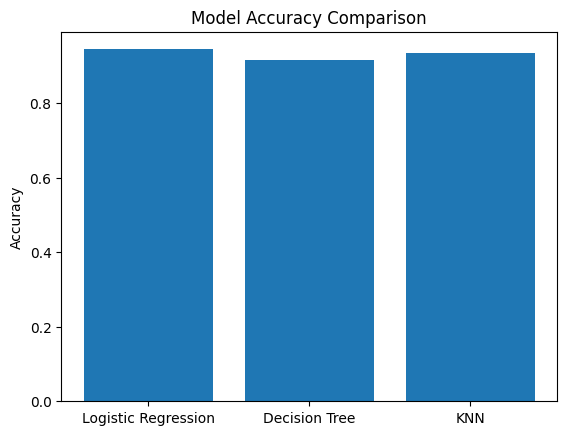

[('Logistic Regression', 0.945), ('Decision Tree', 0.915), ('KNN', 0.935)]


In [50]:
# Import libraries
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Model Accuracy Comparison
models = ['Logistic Regression', 'Decision Tree', 'KNN']

accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, knn_pred)
]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

print(list(zip(models, accuracies)))

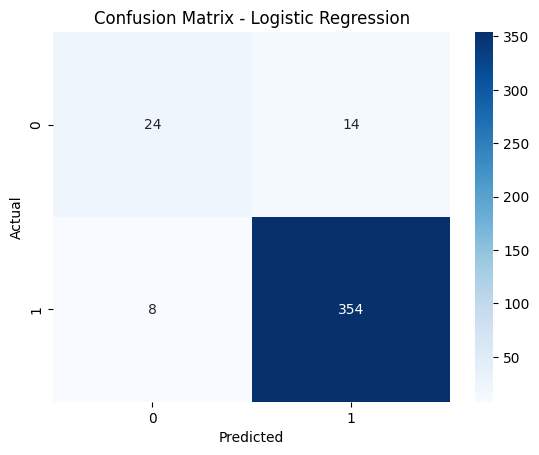

In [51]:
# Import libraries
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix - Logistic Regression
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

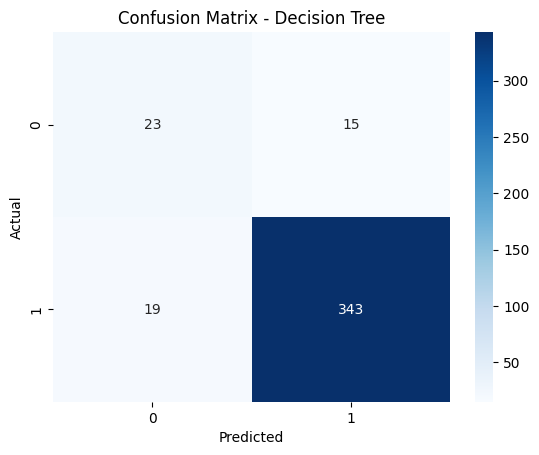

In [54]:
# Confusion Matrix - Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

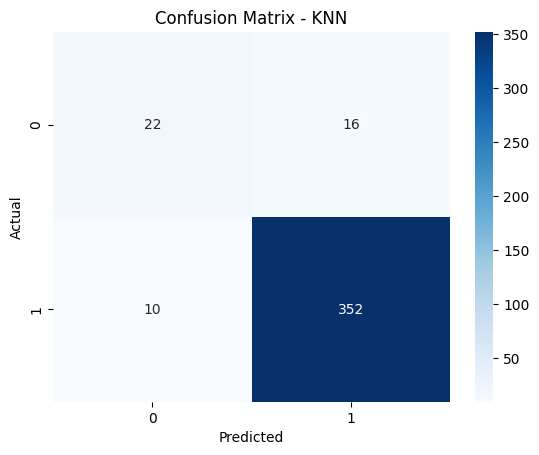

In [55]:
# Confusion Matrix - KNN
cm_knn = confusion_matrix(y_test, knn_pred)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
# Import libraries
from sklearn.metrics import classification_report

# Classification Report
print("Logistic Regression Performance:\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Performance:

              precision    recall  f1-score   support

           0       0.75      0.63      0.69        38
           1       0.96      0.98      0.97       362

    accuracy                           0.94       400
   macro avg       0.86      0.80      0.83       400
weighted avg       0.94      0.94      0.94       400



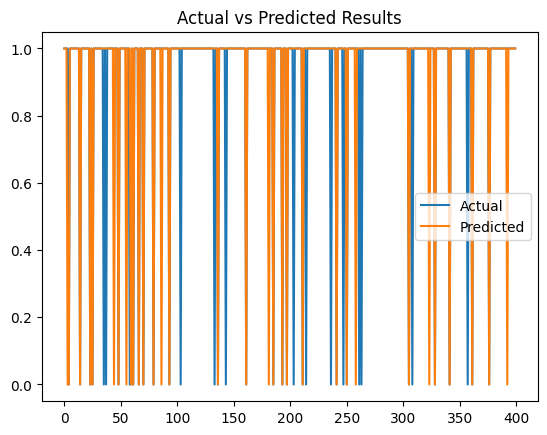

In [57]:
# Actual vs Predicted Visualization
plt.plot(y_test.values, label="Actual")
plt.plot(lr_pred, label="Predicted")
plt.title("Actual vs Predicted Results")
plt.legend()
plt.show()

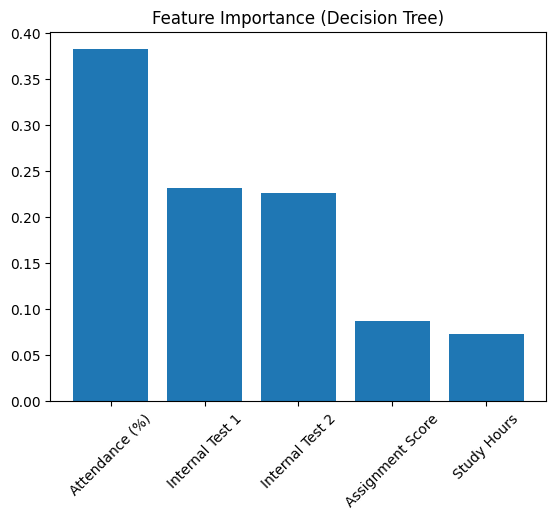

In [58]:
# Import library
import numpy as np

# Feature Importance (Decision Tree)
features = [
    'Attendance (%)',
    'Internal Test 1',
    'Internal Test 2',
    'Assignment Score',
    'Study Hours'
]

importance = dt.feature_importances_

plt.bar(features, importance)
plt.title("Feature Importance (Decision Tree)")
plt.xticks(rotation=45)
plt.show()